In [1]:
import nltk
from nltk.corpus import twitter_samples, stopwords
import matplotlib.pyplot as plt
import random
import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings
import numpy as np

In [2]:
# downloads sample twitter dataset.
# nltk.download('twitter_samples')

# download the stopwords from NLTK
# nltk.download('stopwords')
# plt.close()

def process_tweet(tweet):
    # remove old style retweet text "RT"
    tweet2 = re.sub(r'^RT[\s]+', '', tweet)

    # remove hyperlinks
    tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

    # remove hashtags
    # only removing the hash # sign from the word
    tweet2 = re.sub(r'#', '', tweet2)

    # instantiate tokenizer class
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet2)

    # Import the english stop words list from NLTK
    stopwords_english = stopwords.words('english')

    # print('Stop words\n')
    # print(stopwords_english)

    # print('\nPunctuation\n')
    # print(string.punctuation)

    tweets_clean = []

    for word in tweet_tokens:  # Go through every word in your tokens list
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)

    # Instantiate stemming class
    stemmer = PorterStemmer()

    # Create an empty list to store the stems
    tweets_stem = []

    for word in tweets_clean:
        stem_word = stemmer.stem(word)  # stemming word
        tweets_stem.append(stem_word)  # append to the list

    return tweets_stem

In [3]:
def build_freqs(tweets, ys):
    """Build frequencies.
    Input:
        tweets: a list of tweets
        ys: an m x 1 array with the sentiment label of each tweet
            (either 0 or 1)
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Convert np array to list since zip needs an iterable.
    # The squeeze is necessary or the list ends up with one element.
    # Also note that this is just a NOP if ys is already a list.
    yslist = np.squeeze(ys).tolist()

    # Start with an empty dictionary and populate it by looping over all tweets
    # and over all processed words in each tweet.
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1
    return freqs

In [4]:
def plot_freq(data):
    fig, ax = plt.subplots(figsize=(8, 8))

    # convert positive raw counts to logarithmic scale. we add 1 to avoid log(0)
    x = np.log([x[1] + 1 for x in data])

    # do the same for the negative counts
    y = np.log([x[2] + 1 for x in data])

    # Plot a dot for each pair of words
    ax.scatter(x, y)

    # assign axis labels
    plt.xlabel("Log Positive count")

    plt.ylabel("Log Negative count")

    # Add the word as the label at the same position as you added the points just before
    for i in range(0, len(data)):
        ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

    # Plot the red line that divides the 2 areas.
    ax.plot([0, 9], [0, 9], color='red')
    plt.show()
    plt.close()

In [15]:
def frequency_analysis(tweets):

    # create frequency dictionary
    freqs = build_freqs(tweets, labels)

    # select some words to appear in the report. we will assume that each word is unique (i.e. no duplicates)
    keys = ['happi', 'merri', 'nice', 'good', 'bad', 'sad', 'mad', 'best', 'pretti',
            '❤', ':)', ':(', '😒', '😬', '😄', '😍', '♛',
            'song', 'idea', 'power', 'play', 'magnific']

    # list representing our table of word counts.
    # each element consist of a sublist with this pattern: [<word>, <positive_count>, <negative_count>]
    data = []

    # loop through our selected words
    for word in keys:

        # initialize positive and negative counts
        pos = 0
        neg = 0

        # retrieve number of positive counts
        if (word, 1) in freqs:
            pos = freqs[(word, 1)]

        # retrieve number of negative counts
        if (word, 0) in freqs:
            neg = freqs[(word, 0)]

        # append the word counts to the table
        data.append([word, pos, neg])
    plot_freq(data)

In [16]:
# Select the set of positive and negative tweets
ll_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [20]:
tweet = all_positive_tweets[2277]
proccessed_sentence = process_tweet(tweet)
print(tweet,proccessed_sentence)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i ['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']


In [23]:
# Frequency dict
tweets = all_positive_tweets + all_negative_tweets
# make a numpy array representing labels of the tweets
labels = np.append(np.ones((len(all_positive_tweets))),
                   np.zeros((len(all_negative_tweets))))

tweets[:10],labels[:10]

(['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
  '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
  '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
  '@97sides CONGRATS :)',
  'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days',
  '@BhaktisBanter @PallaviRuhail This one is irresistible :)\n#FlipkartFashionFriday http://t.co/EbZ0L2VENM',
  "We don't like to keep our lovely customers waiting for long! We hope you enjoy! Happy Friday! - LWWF :) https://t.co/smyYriipxI",
  '@Impatientraider On second thought, there’s just not enough time for a DD :) But new shorts entering system. Sheep must be buying.',
  'Jgh , but we have to go to Bayan :D bye',
  'As an act of mischievousness, am calling the ETL layer of our in-house wa

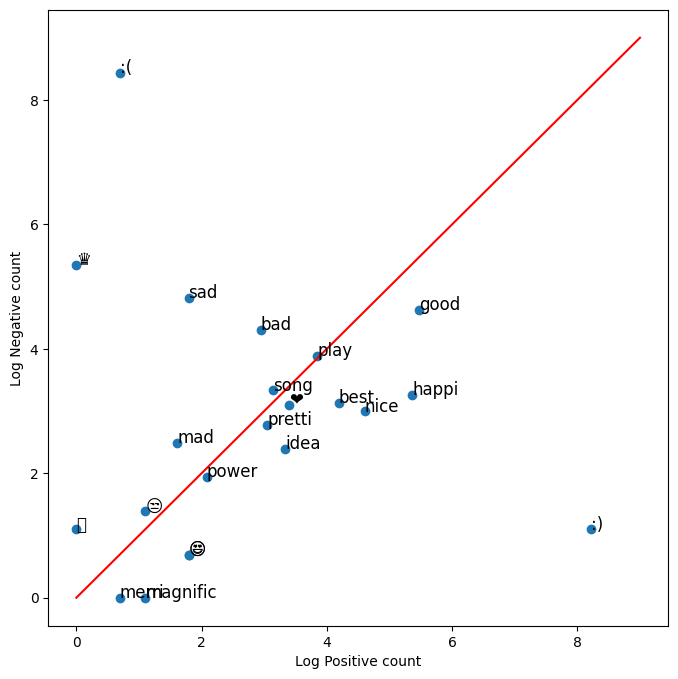

In [24]:
frequency_analysis(tweets)

In [31]:
test_pos = all_positive_tweets[4000:]
train_pos = all_positive_tweets[:4000]
test_neg = all_negative_tweets[4000:]
train_neg = all_negative_tweets[:4000]
train_x = train_pos + train_neg 
test_x = test_pos + test_neg

In [33]:
# combine positive and negative labels
train_y = np.append(np.ones((len(train_pos), 1)), np.zeros((len(train_neg), 1)), axis=0)
test_y = np.append(np.ones((len(test_pos), 1)), np.zeros((len(test_neg), 1)), axis=0)
# Print the shape train and test sets
print("train_y.shape = " + str(train_y.shape))
print("test_y.shape = " + str(test_y.shape))

train_y.shape = (8000, 1)
test_y.shape = (2000, 1)


In [34]:
# create frequency dictionary
freqs = build_freqs(train_x, train_y)

# check the output
print("type(freqs) = " + str(type(freqs)))
print("len(freqs) = " + str(len(freqs.keys())))

type(freqs) = <class 'dict'>
len(freqs) = 11396


In [35]:
# test the function below
print('This is an example of a positive tweet: \n', train_x[0])
print('\nThis is an example of the processed version of the tweet: \n', process_tweet(train_x[0]))

This is an example of a positive tweet: 
 #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)

This is an example of the processed version of the tweet: 
 ['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)']


In [59]:
def sigmoid(z): 
    '''
    Input:
        z: is the input (can be a scalar or an array)
    Output:
        h: the sigmoid of z
    '''
    
    ### START CODE HERE ###
    # calculate the sigmoid of z
    h = 1/(1+np.exp(-z))
    ### END CODE HERE ###
    
    return h

def gradientDescent(x, y, theta, alpha, num_iters):
    '''
    Input:
        x: matrix of features which is (m,n+1)
        y: corresponding labels of the input matrix x, dimensions (m,1)
        theta: weight vector of dimension (n+1,1)
        alpha: learning rate
        num_iters: number of iterations you want to train your model for
    Output:
        J: the final cost
        theta: your final weight vector
    Hint: you might want to print the cost to make sure that it is going down.
    '''
    ### START CODE HERE ###
    # get 'm', the number of rows in matrix x
    m = x.shape[0]
    
    for i in range(0, num_iters):
        
        # get z, the dot product of x and theta
        z = x @ theta
        
        # get the sigmoid of z
        h = sigmoid(z)
        
        # calculate the cost function
        J = -((y.T @ np.log(h)) + ((1-y).T @ np.log(1-h)))/m

        # update the weights theta
        theta = theta - alpha * (x.T @ (h-y))/m
        # print(f"iter : {i}")
        
    ### END CODE HERE ###
    J = J.item()
    return J, theta

In [60]:
def extract_features(tweet, freqs, process_tweet=process_tweet):
    '''
    Input: 
        tweet: a string containing one tweet
        freqs: a dictionary corresponding to the frequencies of each tuple (word, label)
    Output: 
        x: a feature vector of dimension (1,3)
    '''
    # process_tweet tokenizes, stems, and removes stopwords
    word_l = process_tweet(tweet)
    
    # 3 elements for [bias, positive, negative] counts
    x = np.zeros(3) 
    
    # bias term is set to 1
    x[0] = 1 
    
    ### START CODE HERE ###
    # loop through each word in the list of words
    for word in word_l:
        
        # increment the word count for the positive label 1
        x[1] += freqs.get((word,1),0)
        
        # increment the word count for the negative label 0
        x[2] += freqs.get((word,0),0)
        
    ### END CODE HERE ###
    
    x = x[None, :]  # adding batch dimension for further processing
    assert(x.shape == (1, 3))
    return x

In [62]:
# collect the features 'x' and stack them into a matrix 'X'
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :]= extract_features(train_x[i], freqs)

# training labels corresponding to X
Y = train_y

# Apply gradient descent
J, theta = gradientDescent(X, Y, np.zeros((3, 1)), 1e-9, 1500)
print(f"The cost after training is {J:.8f}.")
print(f"The resulting vector of weights is {[round(t, 8) for t in np.squeeze(theta)]}")

The cost after training is 0.22524456.
The resulting vector of weights is [np.float64(6e-08), np.float64(0.00053786), np.float64(-0.00055885)]


In [93]:
def predict_tweet(tweet, freqs, theta):
    '''
    Input: 
        tweet: a string
        freqs: a dictionary corresponding to the frequencies of each tuple (word, label)
        theta: (3,1) vector of weights
    Output: 
        y_pred: the probability of a tweet being positive or negative
    '''
    ### START CODE HERE ###
    
    # extract the features of the tweet and store it into x|
    x = extract_features(tweet, freqs)
    
    # make the prediction using x and theta
    y_pred = sigmoid(x @ theta)
    
    ### END CODE HERE ###
    
    return y_pred

In [94]:
# Feel free to check the sentiment of your own tweet below
my_tweet = 'I am learning :)'
predict_tweet(my_tweet, freqs, theta)

array([[0.83096623]])

In [95]:
def test_logistic_regression(test_x, test_y, freqs, theta, predict_tweet=predict_tweet):
    """
    Input: 
        test_x: a list of tweets
        test_y: (m, 1) vector with the corresponding labels for the list of tweets
        freqs: a dictionary with the frequency of each pair (or tuple)
        theta: weight vector of dimension (3, 1)
    Output: 
        accuracy: (# of tweets classified correctly) / (total # of tweets)
    """
    
    ### START CODE HERE ###
    
    # the list for storing predictions
    y_hat = []
    
    for tweet in test_x:
        # get the label prediction for the tweet
        y_pred = predict_tweet(tweet, freqs, theta)
        
        if y_pred > 0.5:
            # append 1.0 to the list
            y_hat.append(1.0)
        else:
            # append 0 to the list
            y_hat.append(0.0)

    # With the above implementation, y_hat is a list, but test_y is (m,1) array
    # convert both to one-dimensional arrays in order to compare them using the '==' operator
    accuracy = np.sum((np.asanyarray(y_hat) == test_y.squeeze()))/test_y.shape[0]
    ### END CODE HERE ###
    return accuracy

In [96]:
tmp_accuracy = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Logistic regression model's accuracy = {tmp_accuracy:.4f}")

Logistic regression model's accuracy = 0.9965
